# Entrenamiento del Modelo con los datos procesados

In [27]:
import torch
import torch.nn as nn
import numpy as np
import copy
import time
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image


Preparacion de la imagenes en lotes se tiene de las carpetas de train, val, test

In [2]:
DESTINO = Path.cwd().parents[0] / "dataset" / "dataset_bloqueos"
"""
Transofrmaciones 
Redimenciona
voltea
Rota
Cambia color alearorio
Conversion a tensor
Normaliza
"""
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # rotacion de 10 y -10 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # varia brillo y contraste en 20 %
    transforms.ToTensor(), # ResNet valores con los que fueron entrenados y los que espera
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# Sin augmentacion para validar la imagen en el test
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # valores de ResNet que se espera
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(DESTINO / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DESTINO / "val", transform=val_tf)
test_ds  = datasets.ImageFolder(DESTINO / "test", transform=val_tf)

print("Clases:", train_ds.classes)  # debería salir ['bloqueo', 'no_bloqueo']
print(f"train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")
 # organizacion de los datos en lotes de tamaño 32 mezclando
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, num_workers=2)


Clases: ['bloqueo', 'no_bloqueo']
train=3846 | val=554 | test=561


Visualizacion de algunos de algunas de las imagenes que se tiene para entrenamiento

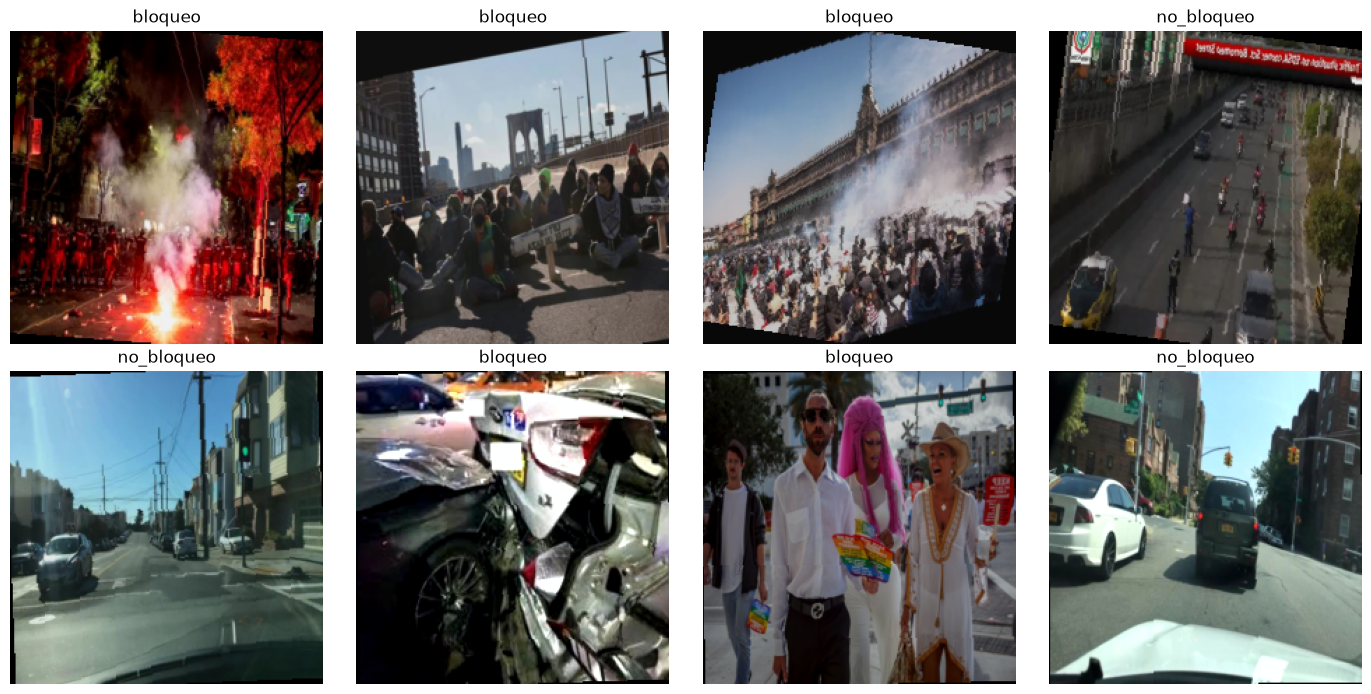

In [ ]:
# Tomamos un lote (batch) del train_loader
imgs, labels = next(iter(train_loader))

# Como las imágenes están normalizadas, hay que desnormalizar para verlas con colores reales
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def desnormalizar(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))  # de (C,H,W) a (H,W,C)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Mostramos 8 imagenes
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
clases = train_ds.classes

for i, ax in enumerate(axes.flat):
    img = desnormalizar(imgs[i])
    ax.imshow(img)
    ax.set_title(clases[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

Dado que se esta usando el modelo preentrenado ResNet18, entonces solo entrenamos la ultima capa para decidir entre bloqueo y no bloqueo

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelamos todas las capas del backbone (el "conocimiento" preentrenado de ImageNet)
# Solo vamos a entrenar la última capa, la que decide bloqueo/no_bloqueo
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la capa final (originalmente clasifica 1000 clases de ImageNet)
# por una nueva capa que clasifica solo 2 (bloqueo / no_bloqueo)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()  # función de pérdida estándar para clasificación
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # solo optimiza la capa nueva

Usando: cuda


Visualizacion de si esta activo la gpu

In [ ]:
print("PyTorch versión:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA compilado en PyTorch:", torch.version.cuda)

PyTorch versión: 2.7.1+cu118
CUDA disponible: True
CUDA compilado en PyTorch: 11.8


Entrenamiento y validacion del modelo duran 10 epocas y guardado del mejor modelo

In [24]:
n_epochs = 10
best_val_acc = 0.0
best_model_weights = None

for epoch in range(n_epochs):
    start = time.time()

    # Entrenamiento
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    #Validación
    model.eval()
    correct, total = 0, 0
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_ds)
    val_acc = correct / total

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{n_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | tiempo={elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())

print(f"\nMejor val_acc: {best_val_acc:.4f}")
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), "mejor_modelo_bloqueos.pth")

Epoch 1/10 | train_loss=0.1424 | val_loss=0.1186 | val_acc=0.9585 | tiempo=21.1s
Epoch 2/10 | train_loss=0.1312 | val_loss=0.1195 | val_acc=0.9621 | tiempo=22.3s
Epoch 3/10 | train_loss=0.1264 | val_loss=0.1166 | val_acc=0.9639 | tiempo=22.4s
Epoch 4/10 | train_loss=0.1410 | val_loss=0.1166 | val_acc=0.9585 | tiempo=22.4s
Epoch 5/10 | train_loss=0.1309 | val_loss=0.1209 | val_acc=0.9657 | tiempo=22.8s
Epoch 6/10 | train_loss=0.1231 | val_loss=0.1160 | val_acc=0.9657 | tiempo=22.5s
Epoch 7/10 | train_loss=0.1239 | val_loss=0.1158 | val_acc=0.9675 | tiempo=22.3s
Epoch 8/10 | train_loss=0.1211 | val_loss=0.1096 | val_acc=0.9639 | tiempo=23.2s
Epoch 9/10 | train_loss=0.1189 | val_loss=0.1131 | val_acc=0.9639 | tiempo=24.0s
Epoch 10/10 | train_loss=0.1177 | val_loss=0.1133 | val_acc=0.9585 | tiempo=23.4s

Mejor val_acc: 0.9675


Verificacion de las imagenes que estan en el test con el modelo ya entrenado, guarda que se predijo comparando con lo que realmente es correcto.

In [ ]:
model.eval()
todas_preds = []
todas_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = out.argmax(1)
        todas_preds.extend(preds.cpu().numpy())
        todas_labels.extend(labels.cpu().numpy())

todas_preds = np.array(todas_preds)
todas_labels = np.array(todas_labels)

acc = (todas_preds == todas_labels).mean()
print(f"Accuracy en test: {acc:.4f}\n")

print(classification_report(todas_labels, todas_preds, target_names=test_ds.classes))

Accuracy en test: 0.9608

              precision    recall  f1-score   support

     bloqueo       0.97      0.93      0.95       227
  no_bloqueo       0.96      0.98      0.97       334

    accuracy                           0.96       561
   macro avg       0.96      0.96      0.96       561
weighted avg       0.96      0.96      0.96       561



Matriz de confusion

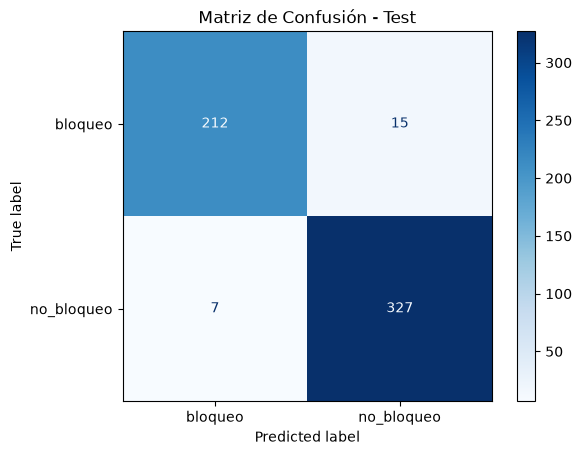

In [26]:
cm = confusion_matrix(todas_labels, todas_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Test")
plt.show()

Verificación de en que imagenes esta fallando o esta dando mal

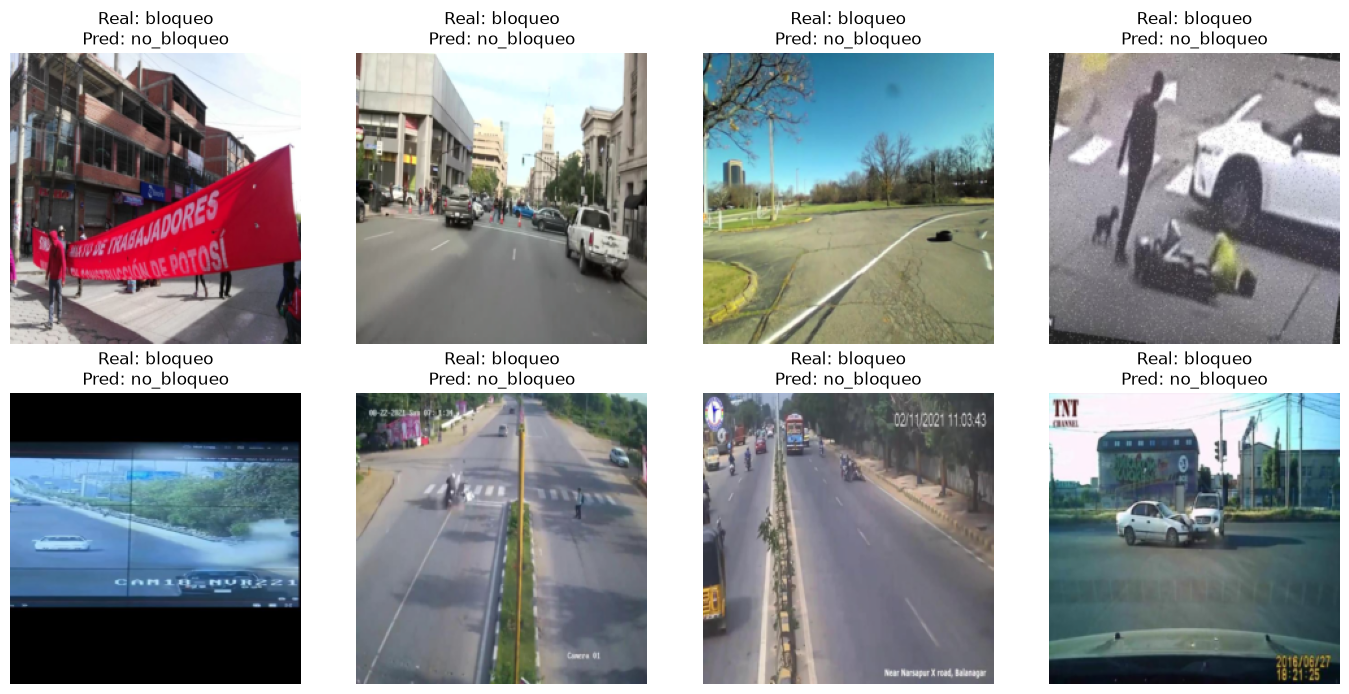

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def desnormalizar(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    return np.clip(img, 0, 1)

model.eval()
errores = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev, labels_dev = imgs.to(device), labels.to(device)
        out = model(imgs_dev)
        preds = out.argmax(1)
        for i in range(len(labels)):
            if preds[i] != labels_dev[i]:
                errores.append((imgs[i], labels[i].item(), preds[i].item()))
        if len(errores) >= 8:
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(errores):
        img, real, pred = errores[i]
        ax.imshow(desnormalizar(img))
        ax.set_title(f"Real: {test_ds.classes[real]}\nPred: {test_ds.classes[pred]}")
        ax.axis("off")
plt.tight_layout()
plt.show()

Probando con imagenes que no conoce el modelo, imagenes nuevas

In [37]:

def predecir_imagen(ruta_imagen, model, transform, clases, device):
    img = Image.open(ruta_imagen).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_t)
        probs = torch.softmax(out, dim=1)
        pred_idx = probs.argmax(1).item()
        confianza = probs[0][pred_idx].item()

    print(f"Predicción: {clases[pred_idx]} (confianza: {confianza:.2%})")
    return clases[pred_idx], confianza

ruta_img = Path.cwd().parents[0] /"test_img"/"normal.jpeg"
predecir_imagen(ruta_img, model, val_tf, test_ds.classes, device)
ruta_img = Path.cwd().parents[0] /"test_img"/"bloqueo.jpeg"
predecir_imagen(ruta_img, model, val_tf, test_ds.classes, device)


Predicción: no_bloqueo (confianza: 94.06%)
Predicción: bloqueo (confianza: 99.99%)


('bloqueo', 0.9998900890350342)